# simplified self attention mechanism without trainable weights 

In [135]:
import torch


In [136]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

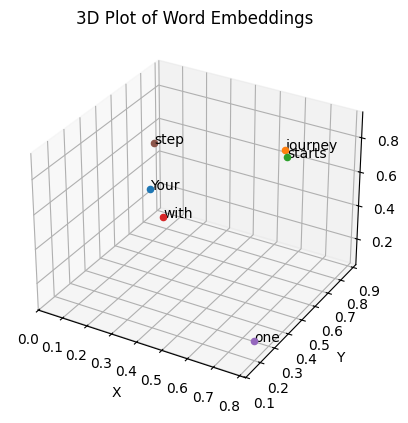

In [137]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

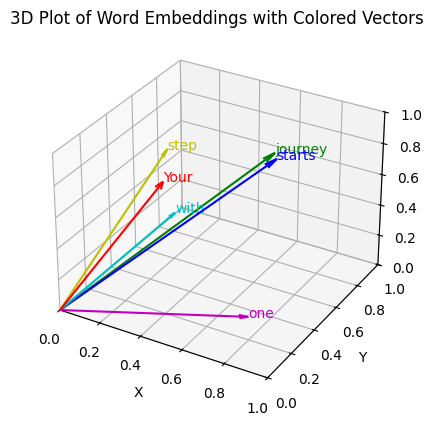

In [138]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


# attention score 

score of relevance of the token wrt to the input and the query using dot product

In [139]:
query = inputs[1]

attnn_score = torch.empty(inputs.shape[0])
for i in range(inputs.shape[0]):
    attnn_score[i] = torch.dot(query, inputs[i])
print(attnn_score)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## one way to normalise is just to take the avg to make all the values between the 0-1 but a much better approch is to do with softmax


### softmax = e^(x1-max)/sum, e^(x2-max)/sum, ....

In [140]:
attnn_score_temp = attnn_score/attnn_score.sum()
print(attnn_score_temp)

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])


naive softmax

In [141]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

In [142]:
attnn_score_norm = torch.nn.functional.softmax(attnn_score, dim=0)
print(attnn_score_norm)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [143]:
attn_score_naive = softmax(attnn_score)
print(attn_score_naive)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


## generating context vector 

In [144]:
query = inputs[1] # 2nd input token is the query

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attnn_score_norm[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


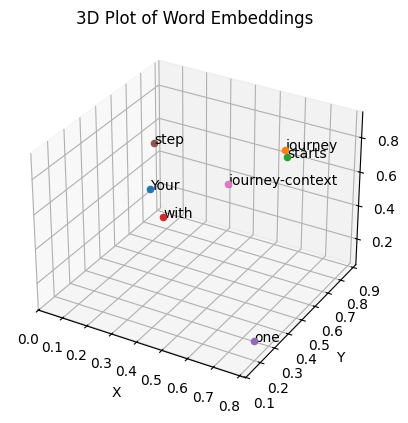

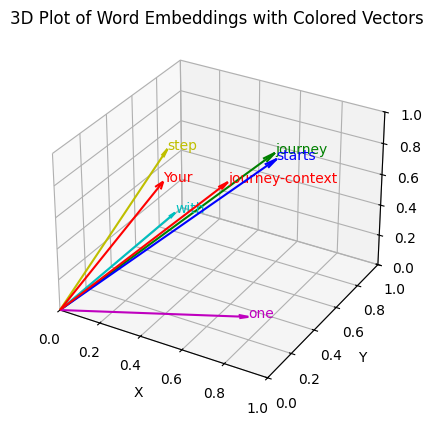

In [145]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

input = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = input[:, 0].numpy()
y_coords = input[:, 1].numpy()
z_coords = input[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors') # type: ignore
plt.show() # type: ignore

In [146]:
attn_scores = torch.empty(6,6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [147]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


dim = -1 as we are insturucting the softmax to work along the last dimention which in our case is the column so the sum along the column would be 1

In [148]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [149]:
attn_weights.shape

torch.Size([6, 6])

In [150]:
context_vecs = attn_weights @ inputs
print(context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## self attention mechanism with trainable weights 

### in this we have 3 trainable weights 
- Wq
    - weight metrix for query
- Wk
    - weight metrix for key
- Wv
    - weight metrix for value 

In [151]:
x_2 = inputs[2]
d_in = inputs.shape[1]
d_out = 2


In [152]:
torch.manual_seed(123) # type: ignore
W_q = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_k = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_v = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_q



Parameter containing:
tensor([[-0.1115,  0.1204],
        [-0.3696, -0.2404],
        [-1.1969,  0.2093]])

In [153]:
query_2 = x_2 @ W_q
key_2 = x_2 @ W_k
value_2 = x_2 @ W_v
print(query_2)

tensor([-1.1438, -0.0018])


In [154]:
key = inputs @ W_k
query = inputs @ W_q
value = inputs @ W_v
print(key)
print(query)
print(value)

tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]])
tensor([[-1.1686,  0.2019],
        [-1.1729, -0.0048],
        [-1.1438, -0.0018],
        [-0.6339, -0.0439],
        [-0.2979,  0.0535],
        [-0.9596, -0.0712]])
tensor([[ 0.1196, -0.3566],
        [ 0.4107,  0.6274],
        [ 0.4091,  0.6390],
        [ 0.2436,  0.4182],
        [ 0.2653,  0.6668],
        [ 0.2728,  0.3242]])


In [155]:
attnscore2 = query_2 @ key.T
print(attnscore2)

tensor([ 0.2098,  0.1320,  0.1665, -0.0489,  0.7408, -0.3725])


## we divide it by root d_key because 
- as softmax is sensitive to the value of inputs if the value on input is hight the output values won't be balanced so to make everything even we use it to ensure stability 
- and aslo because multiplying Q and K increases the varience so to reduce it we divide it by the square root 


In [156]:
final_attn_score = query @ key.T
final_attns_weights = torch.softmax(final_attn_score / torch.sqrt(torch.tensor(key.size(-1))), dim=-1)
print(final_attns_weights)

tensor([[0.1687, 0.1576, 0.1615, 0.1467, 0.2490, 0.1165],
        [0.1704, 0.1611, 0.1652, 0.1412, 0.2505, 0.1117],
        [0.1704, 0.1613, 0.1653, 0.1419, 0.2481, 0.1129],
        [0.1704, 0.1656, 0.1679, 0.1524, 0.2095, 0.1342],
        [0.1680, 0.1651, 0.1661, 0.1622, 0.1856, 0.1529],
        [0.1711, 0.1640, 0.1675, 0.1444, 0.2340, 0.1191]])


In [157]:
attn_output = final_attns_weights @ value
print(attn_output)

tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]])


In [158]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):  # type: ignore
        super().__init__()
        self.W_q = nn.parameter(torch.rand(d_in, d_out)) # type: ignore
        self.W_k = nn.parameter(torch.rand(d_in, d_out)) # type: ignore
        self.W_v = nn.parameter(torch.rand(d_in, d_out)) # type: ignore
    def forward(self, x): # type: ignore
        query = x @ self.W_q # type: ignore
        key = x @ self.W_k # type: ignore
        value = x @ self.W_v # type: ignore

        attn_score = query @ key.T # type: ignore
        attn_weights = torch.softmax(attn_score / torch.sqrt(torch.tensor(key.size(-1))), dim=-1) # type: ignore
        attn_output = attn_weights @ value # type: ignore
        return attn_output # type: ignore

In [159]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self,d_in,d_out,qkv_bias=False):  # type: ignore
        super().__init__()
        self.W_q = nn.Linear(d_in, d_out, bias=qkv_bias) # type: ignore
        self.W_k = nn.Linear(d_in, d_out, bias=qkv_bias) # type: ignore
        self.W_v = nn.Linear(d_in, d_out, bias=qkv_bias) # type: ignore
    def forward(self, x): # type: ignore
        query =  self.W_q(x) # type: ignore
        key =  self.W_k(x) # type: ignore
        value =  self.W_v(x) # type: ignore

        attn_score = query @ key.T # type: ignore
        attn_weights = torch.softmax(attn_score / torch.sqrt(torch.tensor(key.size(-1))), dim=-1) # type: ignore
        attn_output = attn_weights @ value # type: ignore
        return attn_output # type: ignore

In [160]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


# causal attention 
it masks the future token and only considers the current token and the tokens previous to it 

In [161]:
quaries = sa_v2.W_q(inputs)
keys = sa_v2.W_k(inputs)
attn_score = quaries @ keys.T
attn_weights = torch.softmax(attn_score / torch.sqrt(torch.tensor(keys.size(-1))), dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [162]:
context_len = attn_weights.size(0)
mask = torch.tril(torch.ones(context_len, context_len)) 
print(mask)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [163]:
masked_attnn_weights =  attn_weights * mask
print(masked_attnn_weights)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [164]:
row_sums = masked_attnn_weights.sum(dim=1, keepdim=True)
masked_score = masked_attnn_weights / row_sums
print(masked_score)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [165]:
final_attn_score

tensor([[ 0.0740, -0.0216,  0.0126, -0.1230,  0.6250, -0.4498],
        [ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809],
        [ 0.2098,  0.1320,  0.1665, -0.0489,  0.7408, -0.3725],
        [ 0.1458,  0.1061,  0.1254, -0.0118,  0.4384, -0.1919],
        [ 0.0175, -0.0071,  0.0017, -0.0321,  0.1580, -0.1153],
        [ 0.2240,  0.1642,  0.1935, -0.0161,  0.6667, -0.2888]])

In [166]:
masked = torch.triu(torch.ones(context_len, context_len), diagonal=1)
masked_scores = final_attn_score.masked_fill(masked.bool(), -torch.inf)
print(masked_scores)

tensor([[ 0.0740,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.2172,  0.1376,    -inf,    -inf,    -inf,    -inf],
        [ 0.2098,  0.1320,  0.1665,    -inf,    -inf,    -inf],
        [ 0.1458,  0.1061,  0.1254, -0.0118,    -inf,    -inf],
        [ 0.0175, -0.0071,  0.0017, -0.0321,  0.1580,    -inf],
        [ 0.2240,  0.1642,  0.1935, -0.0161,  0.6667, -0.2888]])


In [167]:
masked_attn_weights = torch.softmax(masked_scores / torch.sqrt(torch.tensor(keys.size(-1))), dim=-1)
print(masked_attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5141, 0.4859, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3429, 0.3245, 0.3326, 0.0000, 0.0000, 0.0000],
        [0.2596, 0.2524, 0.2559, 0.2322, 0.0000, 0.0000],
        [0.1983, 0.1949, 0.1961, 0.1915, 0.2191, 0.0000],
        [0.1711, 0.1640, 0.1675, 0.1444, 0.2340, 0.1191]])


## dropout 
it is a process in which some of the neurons are randomly deactivated so that the other neurons are forced to work on their behalf helping in 
- reducing lazy neuron problem 
- reducing overfitting in the model as it helps generalize the weights 

if `p` is the probablity of the neuron to be deactivated the other neurons will be scaled up by the factor `1/1-p`

In [168]:
torch.manual_seed(123) # type: ignore
dropout = torch.nn.Dropout(0.5) #A
example = torch.ones(6, 6) #B
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [169]:
print(dropout(masked_attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6491, 0.6651, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5117, 0.4644, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.4381, 0.0000],
        [0.3422, 0.3280, 0.0000, 0.2888, 0.4680, 0.2381]])


In [170]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

torch.Size([2, 6, 3])


In [171]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

In [172]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


# multihead attention mechanism 

in this we stack multiple single head attention block to operate independently and combine their output 

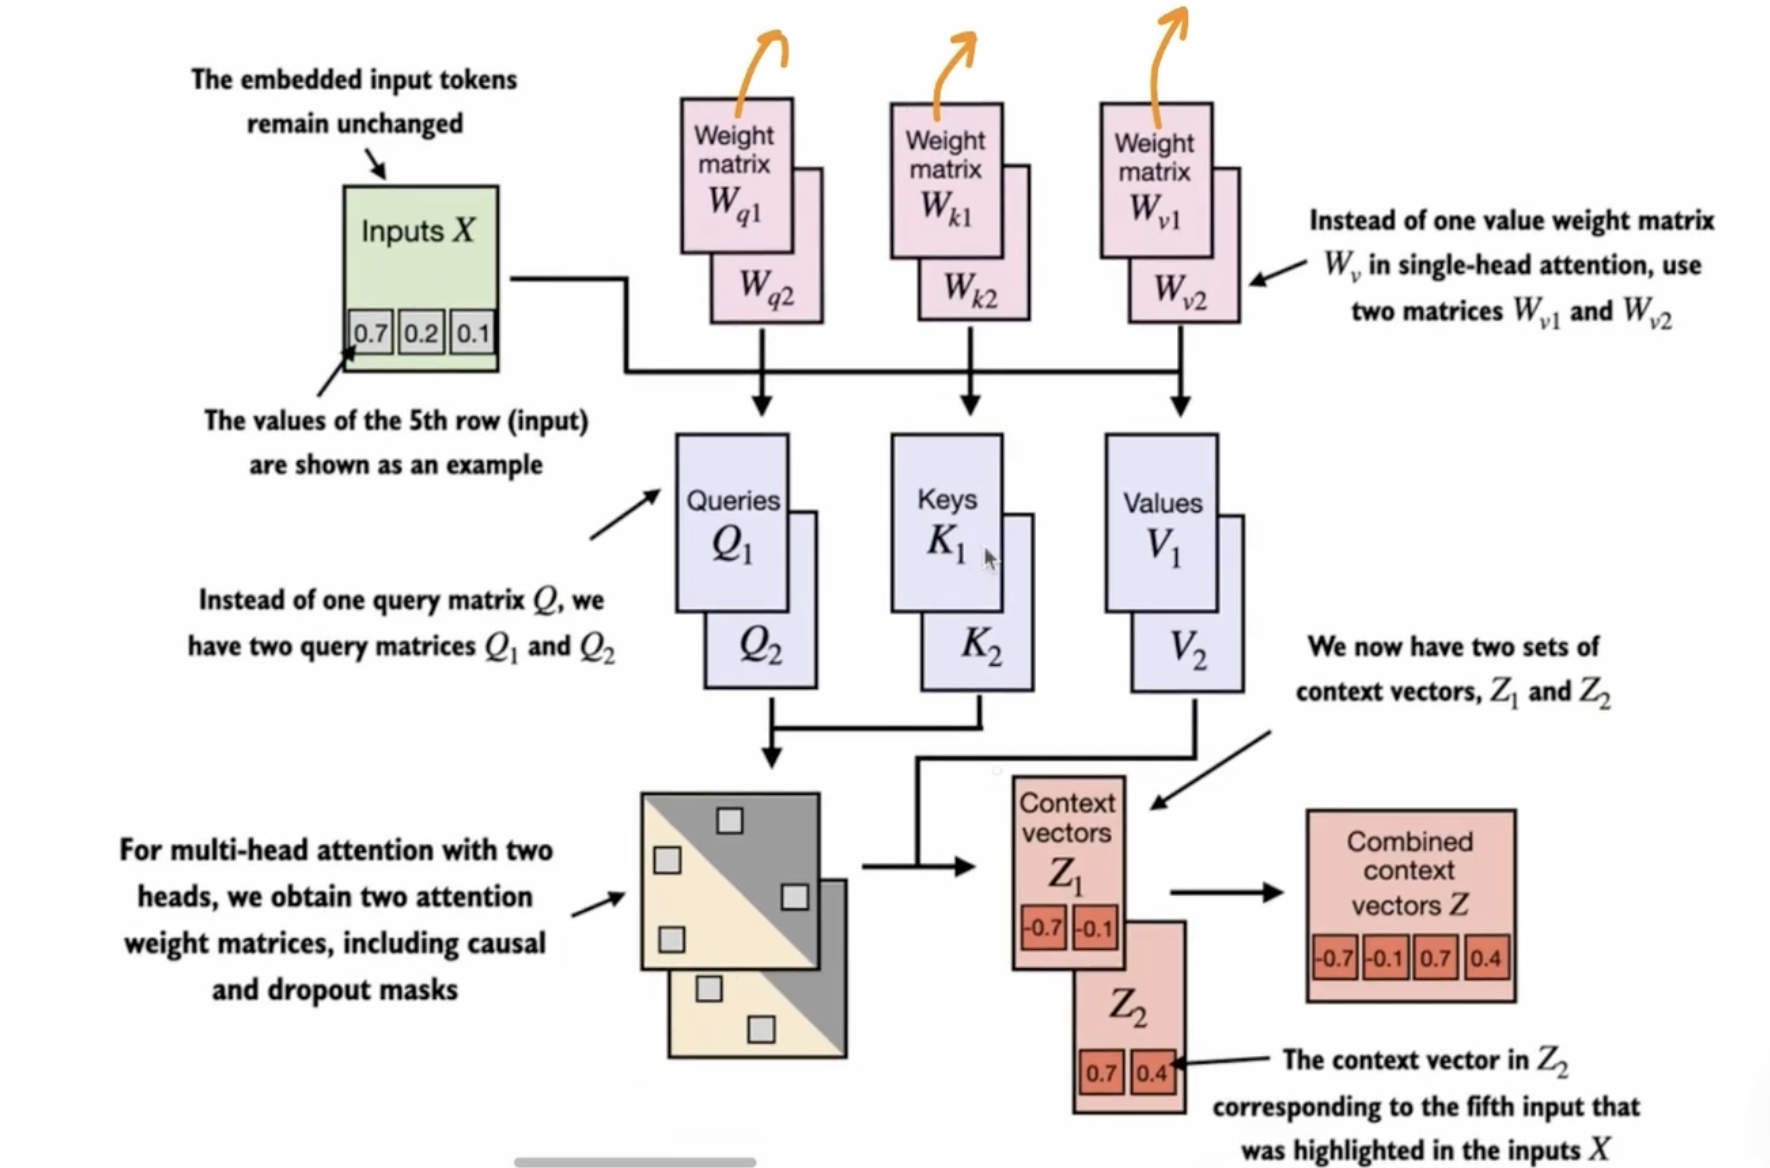

In [173]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


In [174]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)
batch = torch.stack((inputs, inputs), dim=0)
print(batch) 

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])


In [175]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens = 6
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


## multihead attention mechanism with weight splits 
head dimension = d_out/number of heads

In [176]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads 

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) 
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec



Step 1: Reduce the projection dim to match desired output dim

Step 2: Use a Linear layer to combine head outputs

Step 3: Tensor shape: (b, num_tokens, d_out)

Step 4: We implicitly split the matrix by adding a `num_heads` dimension. Then we unroll last dim: (b,
num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)

Step 5: Transpose from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)

Step 6: Compute dot product for each head

Step 7: Mask truncated to the number of tokens

Step 8: Use the mask to fill attention scores

Step 9: Tensor shape: (b, num_tokens, n_heads, head_dim)

Step 10: Combine heads, where self.d_out = self.num_heads * self.head_dim

Step 11: Add an optional linear projection


In [177]:
torch.manual_seed(123)

# Define the tensor with 3 rows and 6 columns
inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # Row 1
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # Row 2
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # Row 3
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 3, 6])
tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])
